<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/Pilot_knowledge_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_df_ipsc.csv to test_df_ipsc.csv
Saving train_df_ipsc.csv to train_df_ipsc.csv
Saving val_df_ipsc.csv to val_df_ipsc.csv


In [ ]:
train_df_ipsc = pd.read_csv('train_df_ipsc.csv')
test_df_ipsc = pd.read_csv('test_df_ipsc.csv')
val_df_ipsc = pd.read_csv('val_df_ipsc.csv')

In [ ]:
drop_cols = ['impeller_d', 'agitation']
train_df_ipsc = train_df_ipsc.drop(columns=drop_cols)
val_df_ipsc = val_df_ipsc.drop(columns=drop_cols)
test_df_ipsc = test_df_ipsc.drop(columns=drop_cols)

train_df_ipsc.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone
0,1,1,101,0.000000,0.3000,0.150,0.915912,0.0,0.153938,1.51,1946.28,0.5,101
1,1,1,101,1.000000,0.0446,0.153,0.897953,0.0,0.153938,1.51,1946.28,0.5,101
2,1,1,101,1.791667,0.0698,0.156,0.880684,0.0,0.153938,1.51,1946.28,0.5,101
3,1,1,101,2.809167,0.3040,0.165,0.957351,0.0,0.161268,1.51,2038.96,0.5,101
4,1,1,101,3.906250,0.6090,0.185,1.108534,0.0,0.175929,1.51,2224.32,0.5,101


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(train_df_ipsc[['clone_id']])

for df in [train_df_ipsc, val_df_ipsc, test_df_ipsc]:
    df['clone_id'] = enc.transform(df[['clone_id']])
    df['clone_id'] = df['clone_id'].astype(int)

In [ ]:
np.random.seed(42)

def augment_sequence (df_group, noise = 0.05):
  aug_df_ipsc = df_group.copy()
  for col in ['p_v', 'vvm', 'tip_speed', 'reynolds']:
    aug_df_ipsc[col] += aug_df_ipsc[col] * np.random.uniform(-noise, noise)
  return aug_df_ipsc

In [ ]:
train_df_ipsc['group_id'] = train_df_ipsc.groupby(['p_id', 'r_id', 'group_clone', 'group_volume']).ngroup()

train_aug_ipsc = []

for group_id, df_group in train_df_ipsc.groupby('group_id'):
    for i in range(2):
        augmented = augment_sequence(df_group)
        augmented['group_id'] = f'{group_id}_aug{i}'
        train_aug_ipsc.append(augmented)
train_df_ipsc['group_id'] = train_df_ipsc['group_id'].astype(str)
train_aug_ipsc = pd.concat([train_df_ipsc] + train_aug_ipsc, ignore_index=True)

train_aug_ipsc.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,1,1,0,0.000000,0.3000,0.150,0.915912,0.0,0.153938,1.51,1946.28,0.5,101,0
1,1,1,0,1.000000,0.0446,0.153,0.897953,0.0,0.153938,1.51,1946.28,0.5,101,0
2,1,1,0,1.791667,0.0698,0.156,0.880684,0.0,0.153938,1.51,1946.28,0.5,101,0
3,1,1,0,2.809167,0.3040,0.165,0.957351,0.0,0.161268,1.51,2038.96,0.5,101,0
4,1,1,0,3.906250,0.6090,0.185,1.108534,0.0,0.175929,1.51,2224.32,0.5,101,0


Save here for scaling dataset CHO + iPSC

In [ ]:
train_aug_ipsc.to_csv('train_aug_ipsc_scaling.csv', index=False)

In [ ]:
files.download('train_aug_ipsc_scaling.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
train_aug_ipsc['group_id'].nunique()

12

In [ ]:
def truncate_to_exponential_phase(df, group_col):
    truncated = []
    for _, group in df.groupby(group_cols):
        peak_idx = group['vcd'].idxmax()
        peak_time = group.loc[peak_idx, 'time']
        buffer_time = peak_time + 3

        exp_phase = group[group['time'] <= buffer_time]
        truncated.append(exp_phase)
    return pd.concat(truncated)

In [ ]:
group_cols = ['p_id', 'r_id', 'group_clone', 'group_volume', 'group_id']
train_aug_ipsc = truncate_to_exponential_phase(train_aug_ipsc, group_cols)

val_df_ipsc['group_id'] = 1
test_df_ipsc['group_id'] = 1

val_df_ipsc = truncate_to_exponential_phase(val_df_ipsc, group_cols)
test_df_ipsc = truncate_to_exponential_phase(test_df_ipsc, group_cols)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving scaler_combined_cho_ipsc.pkl to scaler_combined_cho_ipsc.pkl


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib
scaler = joblib.load("scaler_combined_cho_ipsc.pkl")

In [ ]:
num_cols = ['time', 'vcd', 'volume', 'p_v', 'vvm', 'tip_speed', 'aspect_r', 'reynolds']
train_aug_ipsc[num_cols] = scaler.transform(train_aug_ipsc[num_cols])
test_df_ipsc[num_cols] = scaler.transform(test_df_ipsc[num_cols])
val_df_ipsc[num_cols] = scaler.transform(val_df_ipsc[num_cols])

In [ ]:
test_df_ipsc.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,1,6,1,-0.997560,-0.955142,-0.998165,-0.952345,-1.000000,-0.783588,-1.056604,-0.953962,6.0,102,1
1,1,6,1,-0.877915,-0.967770,-0.998165,-0.952345,-0.043128,-0.783588,-1.056604,-0.953962,6.0,102,1
2,1,6,1,-0.718387,-0.870126,-0.997965,-0.950085,-0.152484,-0.766112,-1.056604,-0.951333,6.0,102,1
3,1,6,1,-0.544988,-0.802582,-0.997660,-0.950217,-0.289181,-0.748635,-1.056604,-0.948704,6.0,102,1
4,1,6,1,-0.378525,-0.179274,-0.997215,-0.954334,0.120908,-0.735527,-1.056604,-0.946732,6.0,102,1


In [ ]:
val_df_ipsc.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,1,4,0,-0.997560,-0.983848,-0.999915,-0.998260,-1.000000,-0.996989,-0.867925,-0.999832,0.5,101,1
1,1,4,0,-0.848437,-0.981646,-0.999915,-0.998260,-1.000000,-0.996989,-0.867925,-0.999832,0.5,101,1
2,1,4,0,-0.666368,-0.976433,-0.999906,-0.999015,-1.000000,-0.996989,-0.867925,-0.999832,0.5,101,1
3,1,4,0,-0.518978,-0.971661,-0.999895,-0.998442,-0.917982,-0.988940,-0.867925,-0.999386,0.5,101,1
4,1,4,0,-0.018548,-0.914910,-0.999857,-0.999465,-0.917982,-0.980892,-0.867925,-0.998940,0.5,101,1


In [ ]:
train_aug_ipsc.head()

,p_id,r_id,clone_id,time,vcd,volume,p_v,vvm,tip_speed,aspect_r,reynolds,group_volume,group_clone,group_id
0,1,1,0,-0.997560,-0.980251,-0.999865,-0.997724,-1.0,-0.972843,-0.867925,-0.998494,0.5,101,0
1,1,1,0,-0.831097,-0.999002,-0.999862,-0.997914,-1.0,-0.972843,-0.867925,-0.998494,0.5,101,0
2,1,1,0,-0.699313,-0.997151,-0.999859,-0.998096,-1.0,-0.972843,-0.867925,-0.998494,0.5,101,0
3,1,1,0,-0.529937,-0.979957,-0.999850,-0.997286,-1.0,-0.964795,-0.867925,-0.998048,0.5,101,0
4,1,1,0,-0.347313,-0.957565,-0.999830,-0.995689,-1.0,-0.948698,-0.867925,-0.997156,0.5,101,0


In [ ]:
feature_cols = [col for col in train_aug_ipsc.columns if col not in group_cols]
train_sort = train_aug_ipsc.sort_values(group_cols + ['time'])
sequences_ipsc = (
    train_sort.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(sequences_ipsc))
print(sequences_ipsc[0].shape)

12
(7, 9)


In [ ]:
for i, seq in enumerate(sequences_ipsc):
    print(f"{i} = {seq.shape}")

0 = (7, 9)
1 = (7, 9)
2 = (7, 9)
3 = (11, 9)
4 = (11, 9)
5 = (11, 9)
6 = (7, 9)
7 = (7, 9)
8 = (7, 9)
9 = (9, 9)
10 = (9, 9)
11 = (9, 9)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
pad = -2.0
padded_sequences_ipsc = pad_sequences(
    sequences_ipsc,
    maxlen=12,
    dtype='float32',
    padding='post',
    value=pad)
print(padded_sequences_ipsc.shape)

(12, 12, 9)


In [ ]:
test_sort_ipsc = test_df_ipsc.sort_values(group_cols + ['time'])

test_sequences_ipsc = (
    test_sort_ipsc.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)
padded_test_sequences_ipsc = pad_sequences(
    test_sequences_ipsc,
    maxlen=12,
    dtype='float32',
    padding='post',
    value=pad)

print(padded_test_sequences_ipsc.shape)
print(len(test_sequences_ipsc))

(2, 12, 9)
2


In [ ]:
val_sort_ipsc = val_df_ipsc.sort_values(group_cols + ['time'])

val_sequences_ipsc = (
    val_sort_ipsc.groupby(group_cols)[feature_cols]
    .apply(lambda x: x.values)
    .tolist()
)

print(len(val_sequences_ipsc))

padded_val_sequences_ipsc = pad_sequences(
    val_sequences_ipsc,
    maxlen=12,
    dtype='float32',
    padding='post',
    value=pad)

print(padded_val_sequences_ipsc.shape)

2
(2, 12, 9)


In [ ]:
vcd_idx = feature_cols.index('vcd')

X_finetune = np.delete(padded_sequences_ipsc, vcd_idx, axis=2)
y_finetune = padded_sequences_ipsc[:, :, vcd_idx]


X_val = np.delete(padded_val_sequences_ipsc, vcd_idx, axis=2)
y_val = padded_val_sequences_ipsc[:, :, vcd_idx]


X_test = np.delete(padded_test_sequences_ipsc, vcd_idx, axis=2)
y_test = padded_test_sequences_ipsc[:, :, vcd_idx]

In [ ]:
y_finetune.shape

(12, 12)

In [ ]:
import tensorflow as tf
y_finetune = tf.expand_dims(y_finetune, axis=-1)
y_val = tf.expand_dims(y_val, axis=-1)
y_test = tf.expand_dims(y_test, axis=-1)

In [ ]:
y_finetune.shape

TensorShape([12, 12, 1])

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving my_model_improved.keras to my_model_improved.keras


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('my_model_improved.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 12, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        37,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 12, 128)        │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 12, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 12, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12, 64)         │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,605 (975.02 KB)

 Trainable params: 83,201 (325.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 166,404 (650.02 KB)

In [ ]:
for layer in model.layers:
    if layer.name in ['bidirectional_1', 'layer_normalization_1', 'dense', 'dense_1']:
        layer.trainable = True
    else:
        layer.trainable = False

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=30, restore_best_weights=True)

history = model.fit(
    X_finetune, y_finetune,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - loss: 0.3932 - mae: 0.8641 - val_loss: 0.1367 - val_mae: 0.6476
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.1998 - mae: 0.6935 - val_loss: 0.1140 - val_mae: 0.5987
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.1120 - mae: 0.6307 - val_loss: 0.1232 - val_mae: 0.5969
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1227 - mae: 0.6321 - val_loss: 0.1308 - val_mae: 0.6020
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.1097 - mae: 0.6226 - val_loss: 0.1352 - val_mae: 0.6064
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1077 - mae: 0.5804 - val_loss: 0.1377 - val_mae: 0.6093
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0993 - mae: 0.6002 - val_loss: 0.1391 - val_mae: 0.6111
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.1085 - mae: 0.6165 - val_loss: 0.1398 - val_mae: 0.6119
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.1048 - mae:

In [ ]:
model.save('my_model_finetuned.keras')

In [ ]:
files.download('my_model_finetuned.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Text(0.5, 1.0, 'Loss over Epochs')

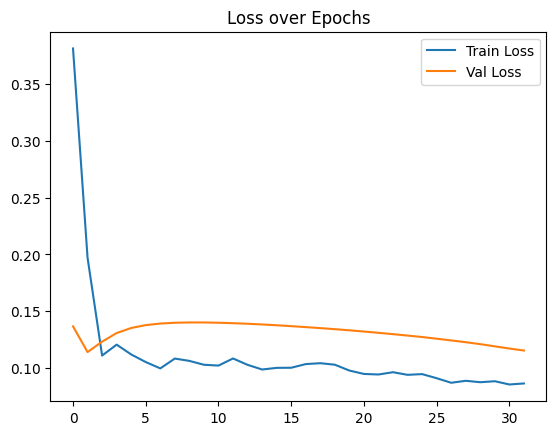

In [ ]:
hist = pd.DataFrame(model.history.history)
plt.plot(hist["loss"], label="Train Loss")
plt.plot(hist["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss over Epochs")

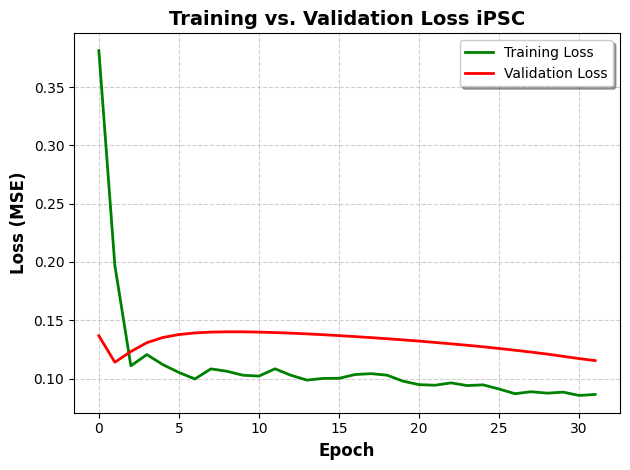

In [ ]:
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color= 'green')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color = 'red')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
plt.title('Training vs. Validation Loss iPSC', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, frameon=True, shadow=True, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

In [ ]:
print(X_test.shape)
print(y_test.shape)

(2, 12, 8)
(2, 12, 1)


In [ ]:
model.evaluate(X_test, y_test)
predicted_vcd = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1716 - mae: 0.8889
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
predicted_vcd = predicted_vcd.squeeze(-1)
y_test = y_test.numpy().squeeze(-1) if isinstance(y_test, tf.Tensor) else y_test.squeeze(-1)

In [ ]:
scaler = joblib.load('scaler_combined_cho_ipsc.pkl')

n_samples, time_steps = predicted_vcd.shape
vcd_idx = list(scaler.feature_names_in_).index('vcd')

flat_pred = predicted_vcd.flatten()
flat_true = y_test.flatten()

dummy_pred = np.zeros((n_samples * time_steps, len(scaler.feature_names_in_)))
dummy_true = np.zeros_like(dummy_pred)

dummy_pred[:, vcd_idx] = flat_pred
dummy_true[:, vcd_idx] = flat_true

inv_pred = scaler.inverse_transform(dummy_pred)[:, vcd_idx]
inv_true = scaler.inverse_transform(dummy_true)[:, vcd_idx]

vcd_pred_original = inv_pred.reshape(n_samples, time_steps)
vcd_true_original = inv_true.reshape(n_samples, time_steps)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mask = y_test != -2.0

masked_true = vcd_true_original[mask]
masked_pred = vcd_pred_original[mask]

mse = mean_squared_error(masked_true, masked_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(masked_true, masked_pred)

print(f"Test RMSE= {rmse:.2f} 10^6 cells/mL")
print(f"Test MAE= {mae:.2f} 10^6 cells/mL")

Test RMSE= 4.05 10^6 cells/mL
Test MAE= 3.01 10^6 cells/mL


In [ ]:
rmse_p = (rmse / vcd_true_original.max()) * 100
mae_p = (mae / vcd_true_original.max()) * 100

print(f"RMSE = {rmse_p:.1f}% of the VCD max in test set.")
print(f"MAE = {mae_p:.1f}% of the VCD max in test set.")

RMSE = 36.1% of the VCD max in test set.
MAE = 26.8% of the VCD max in test set.


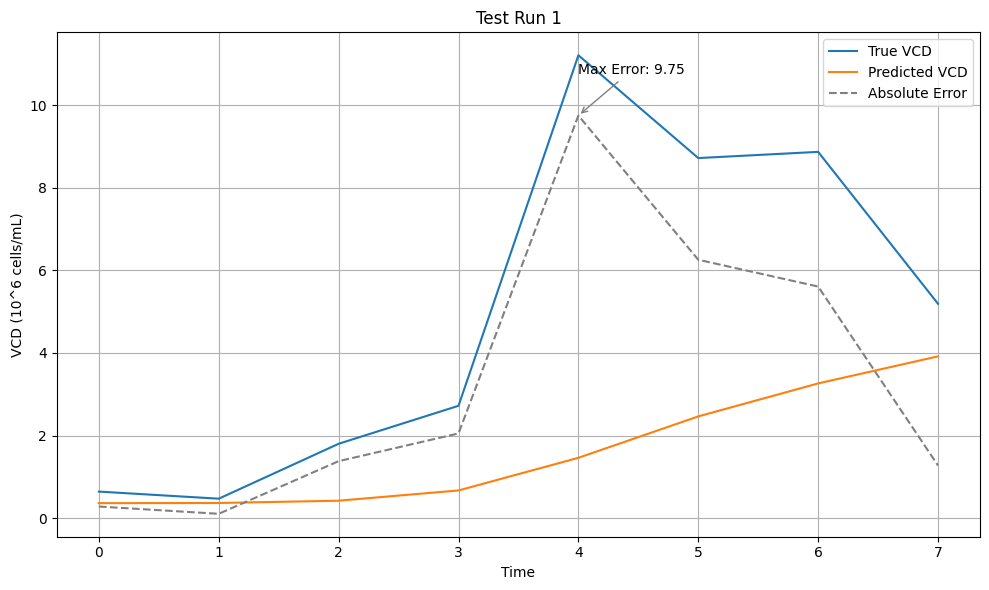

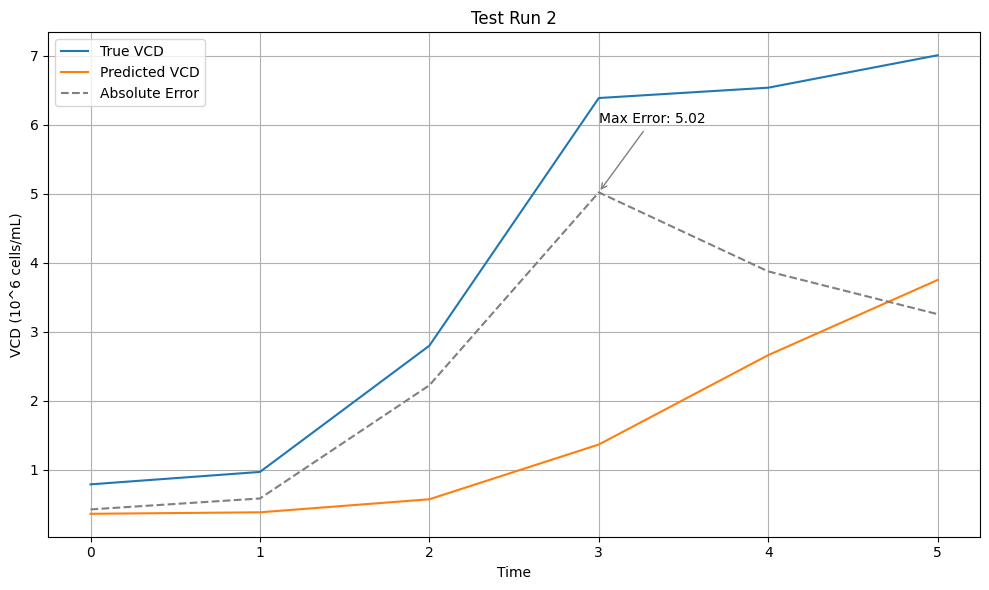

In [ ]:
for i in range(n_samples):
    mask = y_test[i] != -2.0
    time_points = np.arange(sum(mask))
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]
    abs_error = np.abs(true_vals - pred_vals)

    plt.figure(figsize=(10, 6))
    plt.plot(time_points, true_vals, label='True VCD')
    plt.plot(time_points, pred_vals, label='Predicted VCD')
    plt.plot(time_points, abs_error, label='Absolute Error', color='gray', linestyle='--')

    plt.title(f'Test Run {i+1}')
    plt.xlabel('Time')
    plt.ylabel('VCD (10^6 cells/mL)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    max_idx = np.argmax(abs_error)
    plt.annotate(f"Max Error: {abs_error[max_idx]:.2f}",
             xy=(time_points[max_idx], abs_error[max_idx]),
             xytext=(time_points[max_idx], abs_error[max_idx] + 1),
             arrowprops=dict(arrowstyle="->", color='gray'))

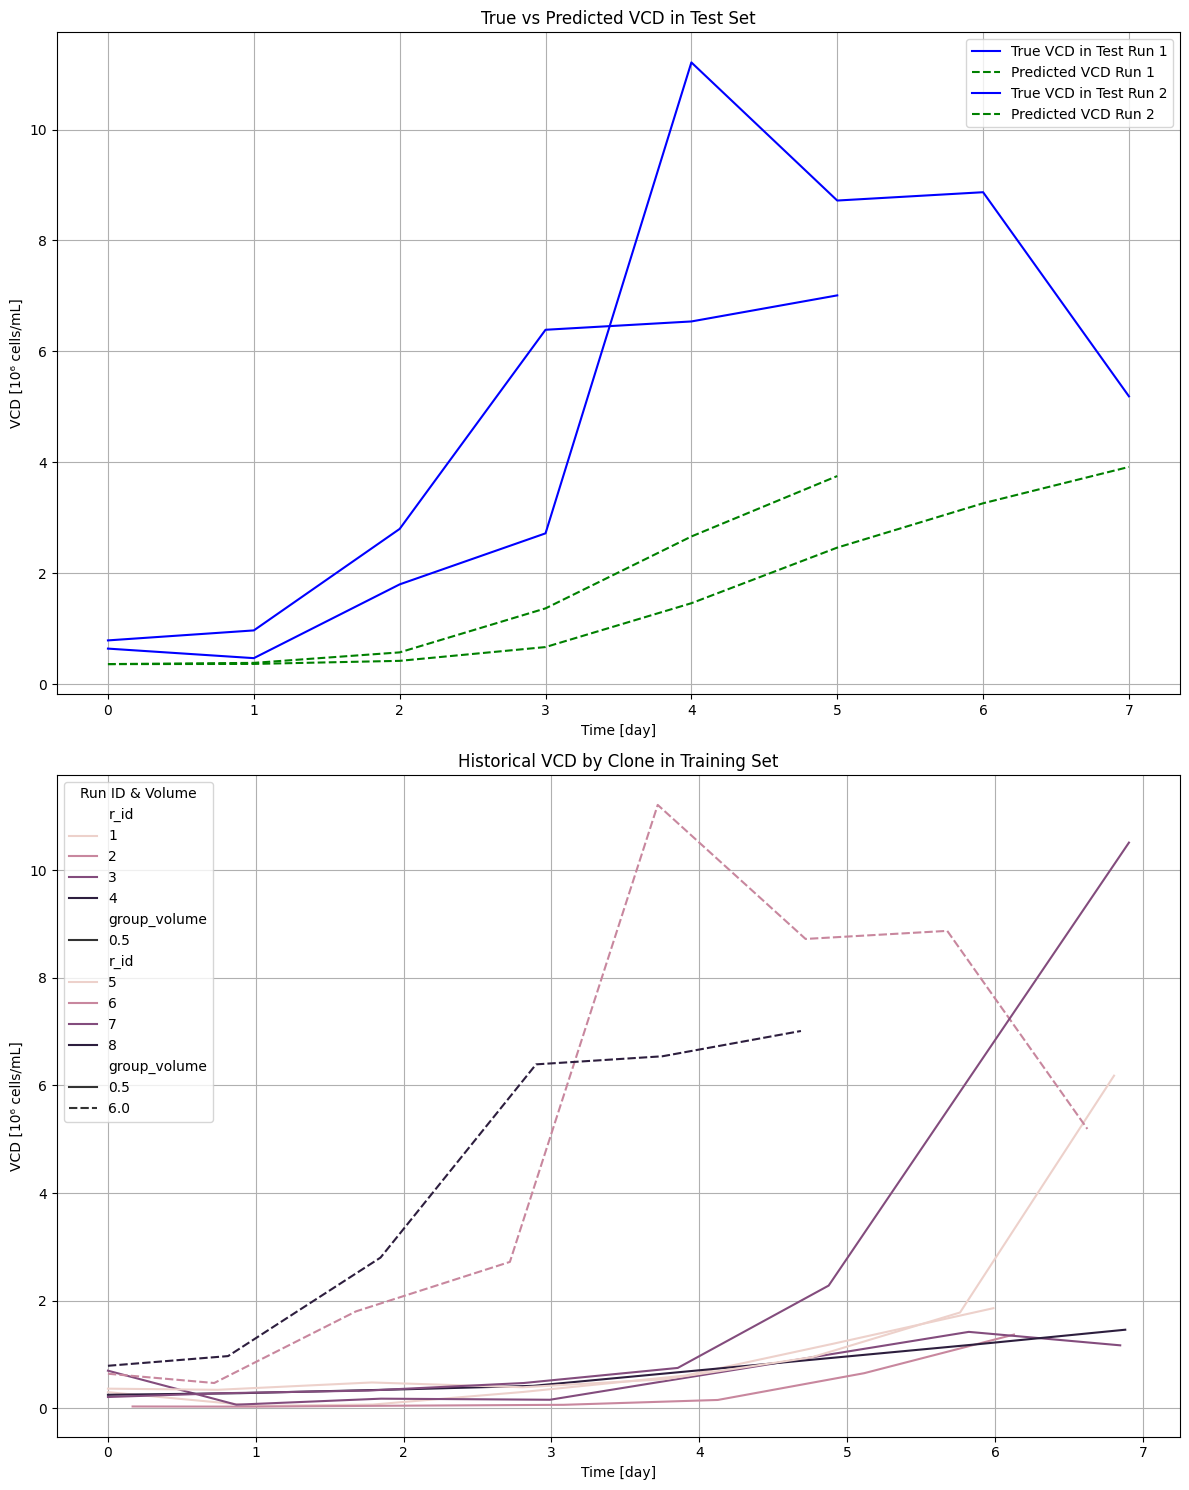

In [ ]:
scaler = joblib.load('scaler_combined_cho_ipsc.pkl')

df = pd.concat([train_aug_ipsc, test_df_ipsc, val_df_ipsc], axis=0).reset_index(drop=True)

vcd_idx = list(scaler.feature_names_in_).index('vcd')
time_idx = list(scaler.feature_names_in_).index('time')

dummy_df_vcd = np.zeros((df.shape[0], len(scaler.feature_names_in_)))
dummy_df_vcd[:, vcd_idx] = df['vcd'].values
df['vcd'] = scaler.inverse_transform(dummy_df_vcd)[:, vcd_idx]

dummy_df_time = np.zeros((df.shape[0], len(scaler.feature_names_in_)))
dummy_df_time[:, time_idx] = df['time'].values
df['time'] = scaler.inverse_transform(dummy_df_time)[:, time_idx]

df = df[df['time'] <= 7].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 15))
ax1 = axes[0]

for i in range(n_samples):
    mask = y_test[i] != -2.0
    time_points = np.arange(sum(mask))
    true_vals = vcd_true_original[i][mask]
    pred_vals = vcd_pred_original[i][mask]

    ax1.plot(time_points, true_vals, label=f'True VCD in Test Run {i+1}', color='blue')
    ax1.plot(time_points, pred_vals, label=f'Predicted VCD Run {i+1}', color='green', linestyle='--')

ax1.set_title('True vs Predicted VCD in Test Set')
ax1.set_xlabel('Time [day]')
ax1.set_ylabel('VCD [10⁶ cells/mL]')
ax1.grid(True)
ax1.legend()

ax2 = axes[1]
for clone in df['clone_id'].unique():
    sns.lineplot(
        data=df[df['clone_id'] == clone],
        x='time', y='vcd',
        hue='r_id',
        style='group_volume',
        errorbar=None,
        ax=ax2
    )

ax2.set_title('Historical VCD by Clone in Training Set')
ax2.set_xlabel('Time [day]')
ax2.set_ylabel('VCD [10⁶ cells/mL]')
ax2.grid(True)
ax2.legend(title='Run ID & Volume')
plt.tight_layout()